

---
---


# PUNTOS CRITICOS


---
---



#**Ejemplo 1:**




Resolvamos numericamente la ecuacion diferencial usando la libreria scipy (a manera de caja negra 🙃!)


\begin{equation}
 \dfrac{d P(t)}{dt} = P (\alpha - \beta P(t))
\end{equation}

<br>

Con:

- $P(0) = 0.2 $

- $\alpha = 0.5$

- $\beta = 0.1$

Graficaremos la solucion numerica obtenida y  tambien la fucion constante $\alpha / \beta$, la cual establece el punto limite de crecimiento.

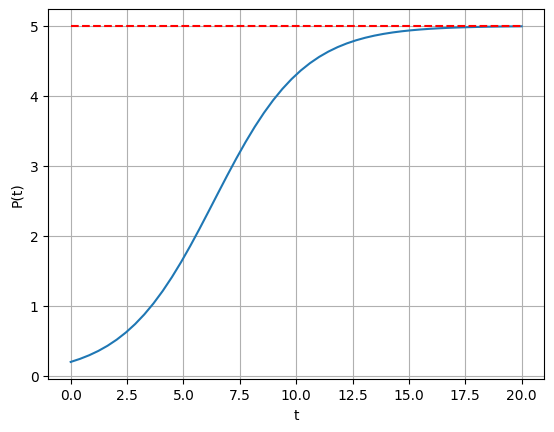

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#---------------------------------
from scipy.integrate import odeint
#---------------------------------



#---parametros del modelo--
beta  = 0.1
alpha = 0.5
#--------------------------


#----- modelo-------
def modelo(p,t):
    return p*( alpha - beta * p)
#--------------------



#poblacion inicial
P0 = 0.2

#lista de tiempo
t = np.linspace(0,20)



#resolviendo la ODE usndo scipy!
P = odeint(modelo,P0,t)


# plot results
plt.plot(t,P)


#------introducir linea constante: B/alpha-------------
plt.plot(t,    np.ones_like(t) *   alpha/beta , 'r--' )
#------------------------------------------------------

plt.grid()
plt.xlabel('t')
plt.ylabel('P(t)')
plt.show()

###¿Que pasa si usamos varias condiciones iniciales para la ODE?

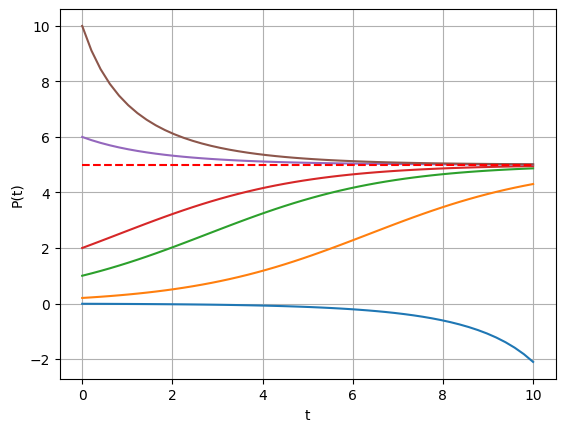

In [ ]:

#poblaciones iniciales
lista_poblaciones_iniciales = [-0.01, 0.2, 1 , 2 , 6, 10 ]


#lista de tiempo
t = np.linspace(0,10)


for Po in lista_poblaciones_iniciales:
    #resolviendo la ODE
    P = odeint(modelo,Po,t)


    #graficamos las funciones obtenidas :)
    plt.plot(t,P)


#------introducir linea constante: B/alpha-------------
plt.plot(t,    np.ones_like(t) *   alpha/beta , 'r--' )
#------------------------------------------------------

plt.grid()
plt.xlabel('t')
plt.ylabel('P(t)')
plt.show()


**Conclusión :** Sin importar el valor de las condiciones iniciales, el  sistema parece evolucionar asintoticamente hacia el mismo valor!!!. Este valor parece atraer todas las soluciones!!!

> Respuesta: decimos que el punto valor es un punto critico del sistema de tipo estable.

#**Ejemplo 2:**




Resolvamos numericamente la ecuacion diferencial usando la libreria scipy (a manera de caja negra 🙃!)


\begin{equation}
 \dfrac{d P(t)}{dt} = k P(t)  
\end{equation}

<br>

Con:

- $P(0) = 0.2 $

- $k = 0.2$


Graficaremos la solucion numerica obtenida y  tambien la fucion constante $0$, la cual establece el punto de equilibrio.


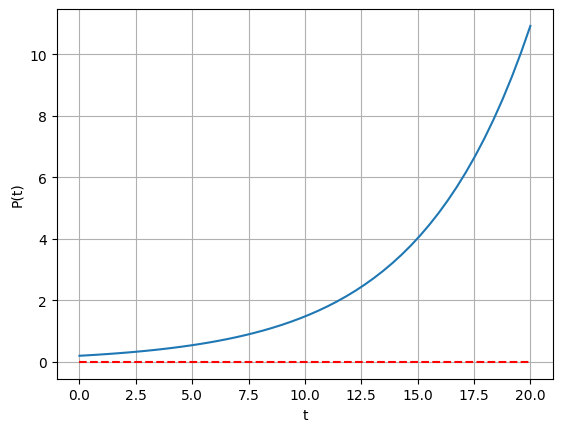

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#---------------------------------
from scipy.integrate import odeint
#---------------------------------



#---parametros del modelo--
k = 0.2
#--------------------------


#----- modelo-------
def modelo(p,t):
    return k * p
#--------------------



#poblacion inicial
P0 = 0.2

#lista de tiempo
t = np.linspace(0,20)


#resolviendo la ODE
P = odeint(modelo,P0,t)


# plot results
plt.plot(t,P)


#------introducir linea constante: 0-------------
plt.plot(t,    np.ones_like(t) *   0  , 'r--' )
#------------------------------------------------------

plt.grid()
plt.xlabel('t')
plt.ylabel('P(t)')
plt.show()

###¿Que pasa si usamos varias condiciones iniciales para la ODE?

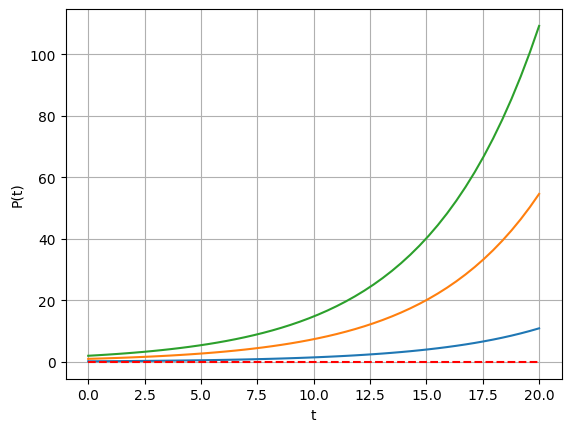

In [ ]:

#poblaciones iniciales
lista_poblaciones_iniciales = [ 0.2, 1 , 2 ]


#lista de tiempo
t = np.linspace(0,20)


for Po in lista_poblaciones_iniciales:
    #resolviendo la ODE
    P = odeint(modelo,Po,t)


    #graficamos las funciones obtenidas :)
    plt.plot(t,P)


#------introducir linea constante: B/alpha-------------
plt.plot(t,    np.ones_like(t) *   0 , 'r--' )
#------------------------------------------------------

plt.grid()
plt.xlabel('t')
plt.ylabel('P(t)')
plt.show()

**Conclusión :** Sin importar el valor de las condiciones iniciales, el *punto critico* parece repeler todas las soluciones!!!


> Entonces: decimos que el punto critico es un repulsor, o punto de silla.

#**Ejemplo 3**

Usando la fisica Newtoniana se obtiene la ecuación de movimiento del pendulo

\begin{equation}
\dfrac{d^2 \theta}{d t^2} + \dfrac{g}{l}\sin\theta  = 0 .
\end{equation}

Esta ecuación es dificil de solucionar de forma exacta por que es NO lineal. Ademas, como es una ecuacion diferencial de segundo orden, tenemos que definir la nueva variable $\omega = \dfrac{d\theta}{d t}$ y asi obtenemos el sistema:

\begin{eqnarray}
\dfrac{d \theta}{d t} &=& \omega, \\
\dfrac{d \omega}{d t} &=& -\dfrac{g}{l}\sin\theta.
\end{eqnarray}


### Solucion usando el metodo de Euler


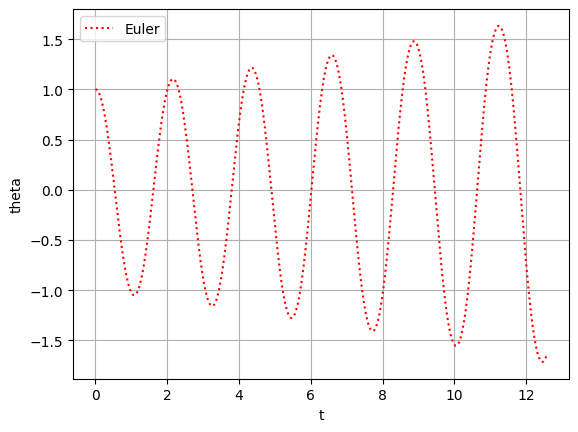

In [1]:
import numpy as np
import matplotlib.pyplot as plt



# Parametros del sistema
g = 9.8
L = 1



#-------Sistema de Ecuaciones diferenciales---------
def F1(theta, omega):
    return omega


def F2(theta, omega):
    return  (- (g/L)*np.sin(theta) )



#--------------------------------------------------



#numero de pasos
t0=0
tf= 4*np.pi
dt = 0.01
t  = np.arange(t0,tf, dt)



# Condiciones inciales
theta0 = 1.0 # Desplazamiento inicial
omega0 = 0.0 # Velocidad inicial


#Llenando un vector de zeros
theta1 = np.zeros(len(t))
omega1 = np.zeros(len(t))


#Llenando los primeros datos
theta1[0] = theta0
omega1[0] = omega0




#Usando el metodo de Euler
for i in range(0, len(t)-1  ):
  theta1[i+1] = theta1[i] + (dt) * F1( theta1[i] , omega1[i] )
  omega1[i+1] = omega1[i] + (dt) * F2( theta1[i] , omega1[i] )


# Graficas
plt.plot(t, theta1, ':r', label ='Euler')
plt.xlabel('t')
plt.ylabel('theta')
plt.grid()
plt.legend()
plt.show()


**NOTA :** Comentar el porque de la diferencia entre los dos graficos y enfatizar en el tamaño de paso.

### Metodo de Adams

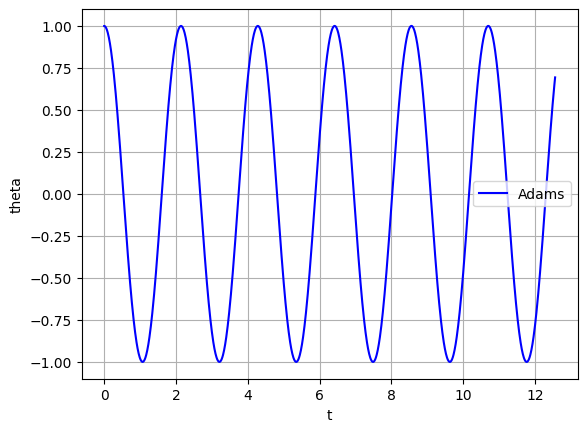

In [2]:
import numpy as np
import matplotlib.pyplot as plt



# Parametros del sistema
g = 9.8
L = 1



#-------Sistema de Ecuaciones diferenciales---------
def F1(theta, omega):
    return omega


def F2(theta, omega):
    return  (- (g/L)*np.sin(theta) )
#--------------------------------------------------



#numero de pasos
t0=0
tf= 4*np.pi
dt = 0.01
t  = np.arange(t0,tf, dt)



# Condiciones inciales
theta0 = 1.0 # Desplazamiento inicial
omega0 = 0.0 # Velocidad inicial


#Llenando un vector de zeros
theta2 = np.zeros(len(t))
omega2 = np.zeros(len(t))


#Llenando los primeros datos
theta2[0] = theta0
omega2[0] = omega0



#Usando el metodo de Euler para el primer paso
theta2[1] = theta2[0] + dt * F1( theta2[0] , omega2[0] )
omega2[1] = omega2[0] + dt * F2( theta2[0] , omega2[0] )



#Usando el metodo de Adams
for i in range(1, len(t)-1  ):
  theta2[i+1] = theta2[i] +  (dt/2) * ( 3* F1( theta2[i] , omega2[i] ) - F1( theta2[i-1] , omega2[i-1] ) )
  omega2[i+1] = omega2[i] +  (dt/2) * ( 3* F2( theta2[i] , omega2[i] ) - F2( theta2[i-1] , omega2[i-1] ) )


# Graficas
plt.plot(t, theta2, '-b', label ='Adams')
plt.xlabel('t')
plt.ylabel('theta')
plt.grid()
plt.legend()
plt.show()

### Comparando las dos soluciones

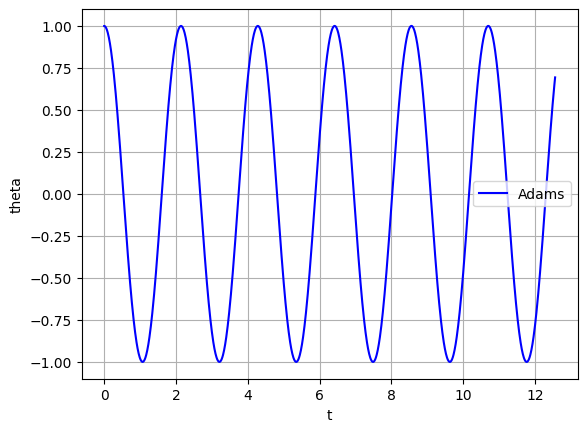

In [3]:
# Graficas
#plt.plot(t, theta1, ':r', label ='Euler')
plt.plot(t, theta2, '-b', label ='Adams')
plt.xlabel('t')
plt.xlabel('t')
plt.ylabel('theta')
plt.grid()
plt.legend()


###Grafico de las trayectorias del sistema

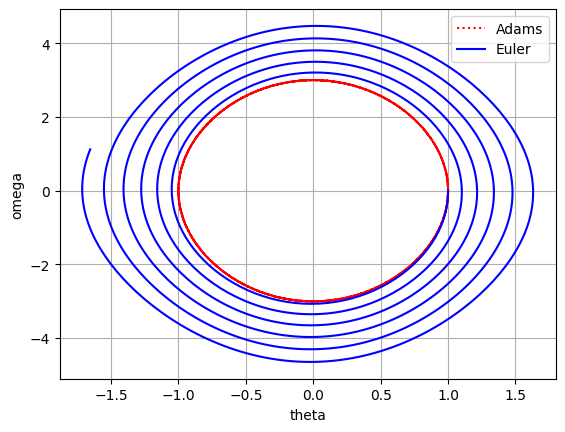

In [5]:
plt.plot(theta2, omega2, ':r', label ='Adams')
plt.plot(theta1, omega1, '-b', label ='Euler')
plt.xlabel('theta')
plt.ylabel('omega')
plt.grid()
plt.legend()
plt.show()

###Variado las condiciones iniciales!

NOTA: Usando del modulo scipy la funcion: odeint

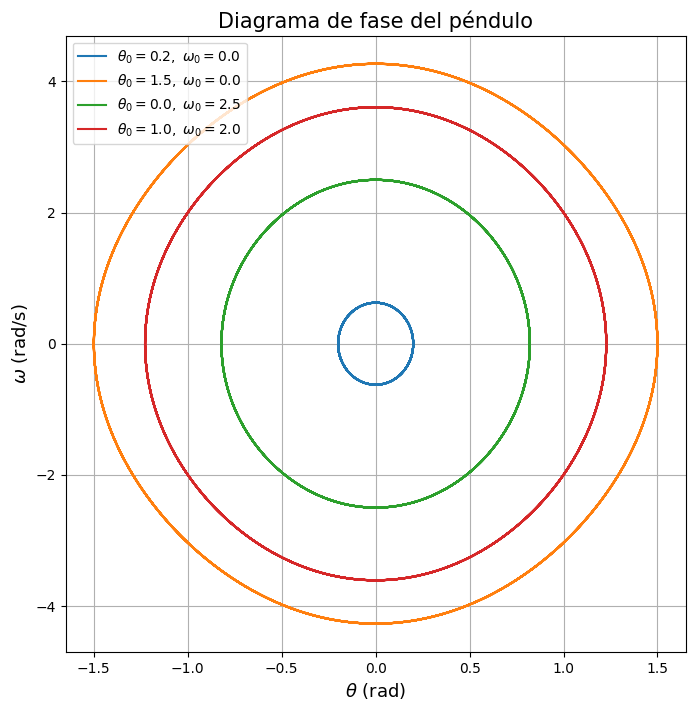

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parámetros
g = 9.81
L = 1.0

# Sistema del péndulo
def pendulo(y, t):
    theta, omega = y
    dtheta = omega
    domega = -(g/L)*np.sin(theta)
    return [dtheta, domega]

# Tiempo de simulación
t = np.linspace(0, 20, 1000)

# Condiciones iniciales (theta0, omega0)
condiciones = [
    [0.2, 0.0],

    [1.5, 0.0],

    [0.0, 2.5],
    [1.0, 2.0]
]

# Gráfica
plt.figure(figsize=(8,8))

for y0 in condiciones:

    sol = odeint(pendulo, y0, t)

    theta = sol[:,0]
    omega = sol[:,1]

    plt.plot(theta, omega,
             label=fr'$\theta_0={y0[0]},\ \omega_0={y0[1]}$')

plt.xlabel(r'$\theta$ (rad)', fontsize=13)
plt.ylabel(r'$\omega$ (rad/s)', fontsize=13)
plt.title('Diagrama de fase del péndulo', fontsize=15)

plt.grid(True)
plt.legend()

plt.show()

#**Ejemplo 4**


###Relajación acoplada en un sistema físico disipativo

Considere un sistema físico donde dos variables dinámicas interactúan:

- $x(t)$: representa una magnitud que se relaja hacia el equilibrio, pero influenciada por $y(t)$ (por ejemplo, una temperatura acoplada a un gradiente térmico).
- $y(t)$: representa una variable disipativa independiente (por ejemplo, una concentración que decae por reacción química de primer orden).

El modelo dinámico está dado por el sistema acoplado:

$$
\begin{aligned}
\frac{dx}{dt} &= -x + y,\\
\frac{dy}{dt} &= -2y.
\end{aligned}
$$

Determine los puntos críticos del sistema, encuentre el diagrama de fase para  diferentes condiciones iniciales e interprete el comportamiento del punto critico


### **Cálculo de los puntos críticos**

Los puntos críticos se obtienen imponiendo

$$
\frac{dx}{dt}=0, \qquad \frac{dy}{dt}=0.
$$

Para el sistema

$$
\begin{aligned}
\frac{dx}{dt} &= -x + y,\\
\frac{dy}{dt} &= -2y,
\end{aligned}
$$

resolvemos el sistema algebraico:

$$
-x + y = 0,
$$

$$
-2y = 0.
$$

De la segunda ecuación se obtiene directamente

$$
y = 0.
$$

Sustituyendo en la primera ecuación:

$$
-x + 0 = 0 \quad \Rightarrow \quad x = 0.
$$

Por lo tanto, el único punto crítico del sistema es

$$
\boxed{(x,y) = (0,0).}
$$

### **Diagrama de fase para diferentes condiciones iniciales**

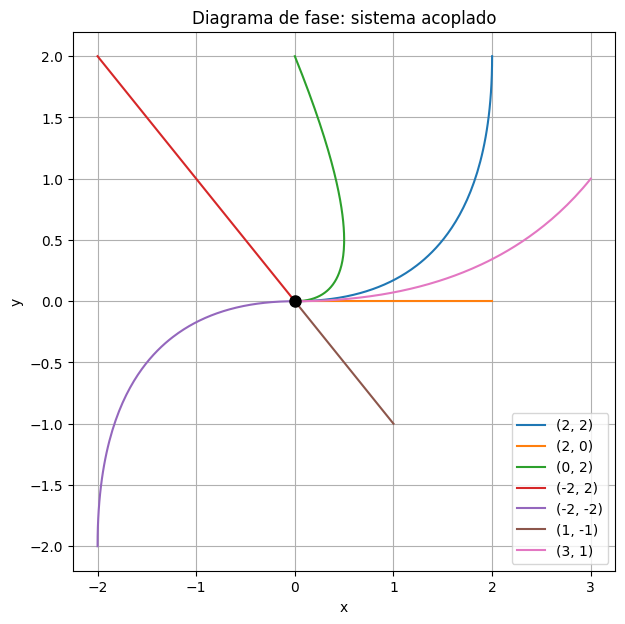

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Sistema acoplado
def sistema(z, t):
    x, y = z
    dx = -x + y
    dy = -2*y
    return [dx, dy]

# Tiempo
t = np.linspace(0, 10, 500)

# Condiciones iniciales
condiciones = [
    [2, 2],
    [2, 0],
    [0, 2],
    [-2, 2],
    [-2, -2],
    [1, -1],
    [3, 1]
]

plt.figure(figsize=(7,7))

# Resolver y graficar trayectorias
for z0 in condiciones:
    sol = odeint(sistema, z0, t)

    x = sol[:,0]
    y = sol[:,1]

    plt.plot(x, y, label=f'({z0[0]}, {z0[1]})')

# Punto crítico
plt.plot(0, 0, 'ko', markersize=8)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Diagrama de fase: sistema acoplado")
plt.grid(True)
plt.legend()
plt.show()